# Adım 7 — Relay Tabanı: eğrinin sıfırı nerede?

**Neden bu notebook var.** Adım 4/5'in grey panelinde eğri `p=0.02`'de ~0.9 tespit gösteriyor
ve bunu "en sinsi grey-hole'ü bile %90 yakalıyoruz" diye okumak cazip. **Bu okuma yanlış
çerçevede.** Çünkü o eğrinin x ekseni yalnız *atağın şiddetini* değiştiriyor — ama `p` ne
olursa olsun ağda **fazladan bir düğüm** var: trafiği önce kendine çeken, sonra ileten bir
relay. Ve bu relay `p=0`'da, yani **tek bir paket bile düşürmezken** de ağı değiştiriyor:
fazladan bir hop, fazladan bir akış, fazladan kuyruk.

**Sorulması gereken soru şu:** tespit ettiğimiz şey *atak* mı, yoksa relay'in salt orada
durmasının izi mi? Bunu ayırmak için eğrinin sıfırını ölçmek gerekir.

**Üç referans seviyesi** (hepsi aynı y ekseninde, "atak denme oranı"):

| Seviye | Ağda ne var | Ne ölçüyor |
|---|---|---|
| **FA** | relay yok, atak yok | normal koşuda yanlış alarm = gerçek taban gürültüsü |
| **R0** | **relay var, atak YOK** (`grey p=0`) | **relay'in kendi izi** |
| eğri(p) | relay var, atak var | relay izi **+** atağın katkısı |

Buradan okunacak iki aralık:
- `R0 − FA` = **relay'in kendi izi** (atak sıfırken bile ödenen bedel),
- `eğri(p) − R0` = **atağın gerçek katkısı** (asıl iddia edebileceğimiz şey).

> **Kapsam kararı:** yoğunluk ekseni **kalır**, relay tabanı **ek** olarak gelir. Biri
> diğerinin yerine geçmez — eğri "şiddet düşünce ne oluyor"u, taban "sıfırda ne kalıyor"u
> anlatıyor. İkisi birlikte anlamlı.

**Veri:** `relay_cost_results.csv` (grey `p=0.0`, 10 koşu) — dataset'te **yok**, ayrı üretildi.
`p=0` bilinçli olarak eğitim setinde değil (Issue 7): davranışı normalden ayırt edilemez olan
bir config eğitim sınıfı olamaz. Aynı kural stealth DoS'a da uygulanıyor (Adım 4/5).

In [1]:
# --- Kütüphaneler ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from scipy import stats                      # eşleştirilmiş t-testi için

# --- Veri (Adım 1/3/5 ile birebir aynı kurulum) ---
cands = [Path("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv"),
         Path("../day3-4-08072026-09072026-dataset/out/dataset.csv")]
DATA = next((p for p in cands if p.exists()), None)
assert DATA is not None, "dataset.csv bulunamadi"
df = pd.read_csv(DATA)

# --- Zararsız relay (grey p=0): AYRI dosya, dataset'te YOK ---
# p=0 eğitim setine bilerek alınmadı (Issue 7): hiç paket düşürmeyen bir "grey-hole"u
# 'greyhole' diye etiketlemek tek vektöre iki anlam yüklemek olurdu. Burada tam da bu
# yüzden değerli: atağı sıfırlanmış relay = eğrinin sıfır noktası.
# Kaynak day8'in relay_cost_results.csv'siydi; o dosya victim_startup_lag_ms'ten ONCE
# uretildi ve sutunu tasimiyor. Ayni kosular guncel hattan gecmis halde prob dosyasinda
# duruyor -- ortak 10 tohumda birebir ayni (max mutlak fark 0.0), ustelik 40 tohum var.
# Bulgunun istatistik tabanini sessizce degistirmemek icin ayni 10 tohuma kisitlaniyor;
# 40'a cikarmak ayri ve bilincli bir karar (iddiayi guclendirir, sayilari degistirir).
RELAY_SEEDS = 10
rcands = [Path("my-work/day3-4-08072026-09072026-dataset/out_probes/dataset.csv"),
          Path("../day3-4-08072026-09072026-dataset/out_probes/dataset.csv")]
RELAY = next((p for p in rcands if p.exists()), None)
assert RELAY is not None, "out_probes/dataset.csv bulunamadi"
relay = pd.read_csv(RELAY).query("scenario == 'relay' and run <= @RELAY_SEEDS").reset_index(drop=True)
assert (relay["intensity"] == 0.0).all(), "relay probu p=0 olmali"
assert len(relay) == RELAY_SEEDS, f"relay probu {len(relay)} satir, {RELAY_SEEDS} bekleniyordu"

# Feature listesi burada TANIMLANMIYOR, my-work/detector_schema.py'den geliyor.
# Kopyalanmis listeler birbirinden ayrilmisti: 02-07 bu ozellik eklenmeden once yazildi
# (12 girdi), 08-10 sonra (13), yayimlanan model 13. check_against_release() semayi
# yayimlanan manifest'e karsi dogruluyor -- buradaki sayilar teslim edilmis modeli
# anlatmiyorsa hucre patlar.
import sys
for _p in ("my-work", "..", "../.."):
    if (Path(_p)/"detector_schema.py").exists(): sys.path.insert(0, _p); break
from detector_schema import FEATURES, build_X, check_against_release
_rel = check_against_release()
print(f"sema surum {_rel['version']} ile uyusuyor ({len(_rel['model']['features'])} girdi)")
CLASS_ORDER = ["normal", "dos", "ddos", "greyhole", "blackhole"]


# --- Stealth prob seti eğitimden çıkar (Adım 4/5 ile aynı kural) ---
PROBE = (df.scenario == "dos") & (df.intensity < 10)
df = df[~PROBE].reset_index(drop=True)

prep = build_X   # tek tanim: detector_schema.build_X
X = build_X(df)
y = df["label_class"]

# --- Hibrit grup kimliği (Adım 5, şema b) ---
SINGLE = {"normal", "blackhole"}                     # tek-config sınıf -> her koşu kendi grubu
groups = df.apply(lambda r: f"{r.scenario}_run{r.run}" if r.scenario in SINGLE
                            else f"{r.scenario}_i{r.intensity}", axis=1)

print(f"eğitim {len(df)} koşu | zararsız relay probu {len(relay)} koşu (grey p=0)")
print(f"X: {X.shape} | toplam grup: {groups.nunique()}")

sema surum v1.1 ile uyusuyor (13 girdi)
eğitim 255 koşu | zararsız relay probu 10 koşu (grey p=0)
X: (255, 13) | toplam grup: 73


## 1. Üç seviyeyi hesapla

**Protokol notu (dürüstlük için önemli).** İki farklı tahmin yolu kullanılıyor ve bu bilinçli:

- **Eğri (grey p=0.02..0.9)** → *config-grupli OOF*. Her yoğunluk noktası, o yoğunluğu **hiç
  görmemiş** bir modelce tahmin ediliyor (Adım 5'in şeması).
- **R0 (relay p=0)** → *tüm eğitim setine fit edilmiş model*. Çünkü `p=0` eğitimde hiç yok,
  dolayısıyla OOF'u da yok. Sorulan soru: "sahadaki detektör, atağı sıfırlanmış bir relay'e ne der?"

Bu, Adım 4/5'te stealth DoS probuna uygulanan protokolün aynısı.

In [2]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0)
sgkf = StratifiedGroupKFold(5, shuffle=True, random_state=0)

# --- Eğri: dürüst (config-grupli) OOF ---
oof = cross_val_predict(rf, X, y, cv=sgkf, groups=groups)
d = df.assign(pred=oof)

# --- Seviye 1: FA = relay YOK, atak YOK ---
FA = (d[d.scenario == "normal"].pred != "normal").mean()

# --- Seviye 2: R0 = relay VAR, atak YOK (probe: tam-fit model) ---
rf_full = clone(rf).fit(X, y)
relay_pred = rf_full.predict(prep(relay))
R0 = (relay_pred != "normal").mean()

# --- Seviye 3: eğri = relay VAR, atak VAR ---
g = (d[d.scenario == "greyhole"]
       .assign(det=lambda t: (t.pred != "normal").astype(int),
               cor=lambda t: (t.pred == t.scenario).astype(int))
       .groupby("intensity")
       .agg(n=("pred", "size"), detect=("det", "mean"), correct=("cor", "mean"))
       .reset_index())

print(f"FA  (relay yok, atak yok) : {FA:.3f}   <- gerçek taban gürültüsü")
print(f"R0  (relay VAR, atak YOK) : {R0:.3f}   <- relay'in kendi izi")
print(f"    relay'in tek başına eklediği tespit: R0 - FA = {R0 - FA:+.3f}")
print()
print("relay p=0 koşuları hangi sınıfa atandı:")
print(pd.Series(relay_pred).value_counts().to_string())
print()

# --- Ayrıştırma: her p'de tespitin ne kadarı atak, ne kadarı relay? ---
dec = g[["intensity", "n", "detect"]].copy()
dec["relay_izi"]    = R0 - FA                      # p'den bağımsız sabit bedel
dec["tavan_payi"]   = 1.0 - R0                     # atağın ekleyebileceği AZAMİ miktar
dec["atak_katkisi"] = dec["detect"] - R0           # atağın gerçekte eklediği
print("=== Tespitin ayrıştırılması ===")
print(dec.round(3).to_string(index=False))
print(f"\n-> relay tek başına tespiti {FA:.3f} -> {R0:.3f} taşıyor.")
print(f"-> atağın ekleyebileceği AZAMİ pay: 1.00 - R0 = {1.0 - R0:.3f}")
if R0 >= 1.0:
    print("-> R0 TAVANDA: zararsız relay detektörü zaten doyuruyor; atağın")
    print("   ekleyecek yeri YOK. Eğri p'ye göre değişemez, çünkü zaten tavanda.")

FA  (relay yok, atak yok) : 0.150   <- gerçek taban gürültüsü
R0  (relay VAR, atak YOK) : 1.000   <- relay'in kendi izi
    relay'in tek başına eklediği tespit: R0 - FA = +0.850

relay p=0 koşuları hangi sınıfa atandı:
greyhole    10

=== Tespitin ayrıştırılması ===
 intensity  n  detect  relay_izi  tavan_payi  atak_katkisi
      0.02 10     1.0       0.85         0.0           0.0
      0.05 10     1.0       0.85         0.0           0.0
      0.10 10     1.0       0.85         0.0           0.0
      0.20 10     1.0       0.85         0.0           0.0
      0.30 10     1.0       0.85         0.0           0.0
      0.40 10     1.0       0.85         0.0           0.0
      0.50 10     1.0       0.85         0.0           0.0
      0.60 10     1.0       0.85         0.0           0.0
      0.70 10     1.0       0.85         0.0           0.0
      0.80 10     1.0       0.85         0.0           0.0
      0.90 10     1.0       0.85         0.0           0.0

-> relay tek başına tesp

### Kontrol — bu sonuç döngüsel olmasın

**İtiraz:** yukarıdaki R0, `p=0.02..0.9`'u **görerek** eğitilmiş bir modelden geldi. Model
`p=0.02`'yi (delivery 0.895) `greyhole` diye öğrendiyse, ona çok benzeyen `p=0`'a (0.902)
`greyhole` demesi şaşırtıcı değil — kısmen döngüsel.

**Döngüyü kesen deney:** `p=0` **ve** `p=0.02`'nin **ikisini birden** eğitimden çıkar, sonra
ikisini de sor. Model artık ikisini de hiç görmemiş durumda ve aralarında ayrım yapmak için
hiçbir gerekçesi yok. Eğer ikisine de aynı şeyi diyorsa, iddia sağlam:

> detektör "**hiç düşürmeyen relay**" ile "**%2 düşüren relay**"i ayırt edemiyor.

In [3]:
# p=0 zaten eğitimde yok; p=0.02'yi de çıkar -> ikisi de "görülmemiş"
is002 = (df.scenario == "greyhole") & (df.intensity == 0.02)
m2 = clone(rf).fit(X[~is002.to_numpy()], y[~is002.to_numpy()])

pred_p0   = m2.predict(prep(relay))                 # relay VAR, atak YOK  (hiç görülmedi)
pred_p002 = m2.predict(prep(df[is002]))             # relay VAR, %2 drop   (hiç görülmedi)

print("İkisi de eğitimde YOK. Aynı modele soruldu:\n")
for name, pr_ in [("relay p=0    (atak YOK)", pred_p0), ("grey  p=0.02 (%2 drop)", pred_p002)]:
    vc = pd.Series(pr_).value_counts()
    det = (pr_ != "normal").mean()
    print(f"  {name}: tespit={det:.2f} | {dict(vc)}")

same = (pd.Series(pred_p0).value_counts().idxmax() ==
        pd.Series(pred_p002).value_counts().idxmax())
print(f"\n-> ikisi de ağırlıklı olarak AYNI sınıfa mı gidiyor? {'EVET' if same else 'HAYIR'}")
print("   Evet ise: detektör 'hiç düşürmeyen relay' ile '%2 düşüren relay'i ayıramıyor;")
print("   yani p=0.02'deki tespit atağın değil, relay'in varlığının eseri. Döngü yok.")

İkisi de eğitimde YOK. Aynı modele soruldu:

  relay p=0    (atak YOK): tespit=1.00 | {'greyhole': np.int64(10)}
  grey  p=0.02 (%2 drop): tespit=1.00 | {'greyhole': np.int64(9), 'dos': np.int64(1)}

-> ikisi de ağırlıklı olarak AYNI sınıfa mı gidiyor? EVET
   Evet ise: detektör 'hiç düşürmeyen relay' ile '%2 düşüren relay'i ayıramıyor;
   yani p=0.02'deki tespit atağın değil, relay'in varlığının eseri. Döngü yok.


## 2. Figür L — aynı hikâye iki irtifada

**Sol panel (tespit uzayı):** eğri + iki yatay referans. Amber bant = relay'in kendi izi
(atak sıfırken bile ödenen), mavi bant = atağın katkısı. Eğri amber çizgiye yapışıksa, o
yoğunlukta atak **hiçbir şey eklemiyor** demektir.

**Sağ panel (feature uzayı):** aynı şey mekanizma düzeyinde, `delivery_ratio` üzerinde —
tespit neden öyle davranıyor? Normal bandı **seed-eşleştirilmiş** (aşağıda gerekçesi).

x ekseni **log**: iddianın geçtiği yer stealth uç (p=0.02–0.1); doğrusal eksende o üç nokta
eksenin %10'una sıkışıp görünmez oluyordu. (Adım 4/5'in DoS paneli de aynı sebeple log.)

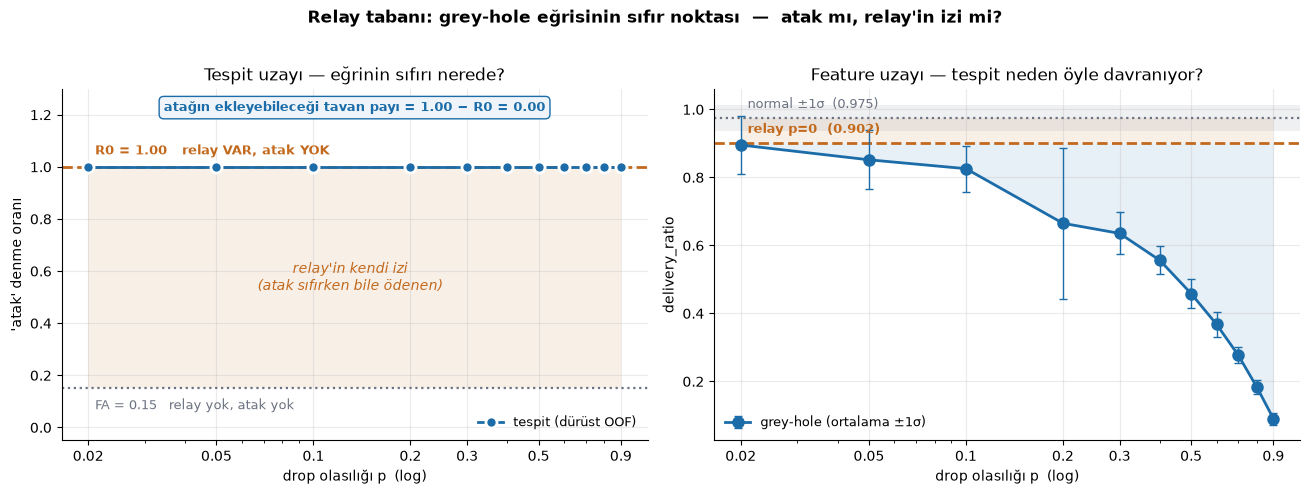

In [4]:
# --- Palet (dataviz validator ile doğrulandı: lightness/chroma/CVD/kontrast 6/6 PASS) ---
C_RELAY  = "#c2691d"   # amber  = relay (zararsız, atak yok)
C_ATTACK = "#1b6ca8"   # mavi   = grey-hole atağı / tespit  (Adım 4/5 konvansiyonu)
C_INK    = "#6b7280"   # nötr   = normal referansı (kategorik seri değil, annotation)

# --- Seed-eşleştirilmiş normal (gerekçe: sonraki hücre) ---
NR = sorted(relay.run.unique())                       # relay tohumları: 1..10
nrm_all = df[df.scenario == "normal"]
nrm_m   = nrm_all[nrm_all.run.isin(NR)]               # aynı tohumlarla normal

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
XT = [0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.9]

# ================= Panel 1: tespit uzayı =================
ax = axes[0]
xs = g["intensity"].to_numpy()
ys = g["detect"].to_numpy()

# Amber bant = relay'in kendi izi. R0 tavandaysa bu bant panelin TAMAMINI kaplar --
# görsel mesaj tam da bu: eğrinin altındaki her şey relay, atağa yer kalmıyor.
ax.fill_between(xs, FA, R0, color=C_RELAY, alpha=0.10, lw=0)
# Atak katkısı bandı yalnız GERÇEKTEN varsa çizilir (R0 < 1). R0 tavandayken
# çizilecek bir şey yok -- hayalet bant koymuyoruz.
if R0 < 1.0:
    ax.fill_between(xs, R0, ys, where=ys >= R0, color=C_ATTACK, alpha=0.10, lw=0)

ax.axhline(FA, color=C_INK, lw=1.6, ls=":")
ax.axhline(R0, color=C_RELAY, lw=2, ls="--")
# markeredgecolor=yüzey halkası: eğri R0 çizgisiyle çakışıyor, halka olmadan
# hangisinin nerede olduğu okunmuyor.
ax.plot(xs, ys, "o-", color=C_ATTACK, lw=2, ms=8, label="tespit (dürüst OOF)",
        markeredgecolor="white", markeredgewidth=2)

ax.annotate(f"R0 = {R0:.2f}   relay VAR, atak YOK", xy=(0.021, R0), xytext=(0, 9),
            textcoords="offset points", color=C_RELAY, fontsize=9.5, fontweight="bold")
ax.annotate(f"FA = {FA:.2f}   relay yok, atak yok", xy=(0.021, FA), xytext=(0, -15),
            textcoords="offset points", color=C_INK, fontsize=9.5)
ax.annotate("relay'in kendi izi\n(atak sıfırken bile ödenen)", xy=(0.13, (FA + R0) / 2),
            color=C_RELAY, fontsize=10, style="italic", ha="center", va="center")

# Asıl bulgu, panelin İÇİNE (başlığın altına) yazılıyor.
ax.text(0.5, 0.965, f"atağın ekleyebileceği tavan payı = 1.00 − R0 = {1.0 - R0:.2f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=9.5,
        fontweight="bold", color=C_ATTACK,
        bbox=dict(boxstyle="round,pad=0.35", fc="#eef4f9", ec=C_ATTACK, lw=1))

ax.set_xscale("log"); ax.set_xticks(XT); ax.set_xticklabels([str(t) for t in XT])
ax.set_ylim(-0.05, 1.30)
ax.set_xlabel("drop olasılığı p  (log)")
ax.set_ylabel("'atak' denme oranı")
ax.set_title("Tespit uzayı — eğrinin sıfırı nerede?")
ax.legend(loc="lower right", frameon=False, fontsize=9)

# ================= Panel 2: feature uzayı =================
ax = axes[1]
gd = (df[df.scenario == "greyhole"].groupby("intensity")["delivery_ratio"]
        .agg(["mean", "std"]).reset_index())
xs2 = gd["intensity"].to_numpy(); ys2 = gd["mean"].to_numpy()

n_mu, n_sd = nrm_m.delivery_ratio.mean(), nrm_m.delivery_ratio.std()
r_mu = relay.delivery_ratio.mean()

ax.fill_between(xs2, n_mu, r_mu, color=C_RELAY, alpha=0.10, lw=0)
ax.fill_between(xs2, r_mu, ys2, where=ys2 <= r_mu, color=C_ATTACK, alpha=0.10, lw=0)
ax.axhspan(n_mu - n_sd, n_mu + n_sd, color=C_INK, alpha=0.10, lw=0)   # normal ±1σ
ax.axhline(n_mu, color=C_INK, lw=1.6, ls=":")
ax.axhline(r_mu, color=C_RELAY, lw=2, ls="--")
ax.errorbar(xs2, ys2, yerr=gd["std"], fmt="o-", color=C_ATTACK, lw=2, ms=8,
            capsize=3, elinewidth=1, label="grey-hole (ortalama ±1σ)")

ax.annotate(f"relay p=0  ({r_mu:.3f})", xy=(0.021, r_mu), xytext=(0, 7),
            textcoords="offset points", color=C_RELAY, fontsize=9.5, fontweight="bold")
ax.annotate(f"normal ±1σ  ({n_mu:.3f})", xy=(0.021, n_mu), xytext=(0, 7),
            textcoords="offset points", color=C_INK, fontsize=9.5)

ax.set_xscale("log"); ax.set_xticks(XT); ax.set_xticklabels([str(t) for t in XT])
ax.set_xlabel("drop olasılığı p  (log)")
ax.set_ylabel("delivery_ratio")
ax.set_title("Feature uzayı — tespit neden öyle davranıyor?")
ax.legend(loc="lower left", frameon=False, fontsize=9)

for a in axes:
    a.grid(alpha=0.25)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)

fig.suptitle("Relay tabanı: grey-hole eğrisinin sıfır noktası  —  atak mı, relay'in izi mi?",
             fontsize=12.5, fontweight="bold", y=1.02)
fig.tight_layout()
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
fig.savefig(FIGS / "L-relay-tabani.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Seed eşleştirmesi — neden şart?

`normal` 40 tohumla, `relay`/`grey` 10 tohumla koşuldu. Ward'daki aktif cihaz alt-kümesi
koşu-başı rastgele olduğu için (Aşama 2), normal'in **40-tohum ortalaması kendi 10-tohum
alt kümesinden sapıyor**. Eşleştirmeden σ hesaplamak bu yüzden yanıltıcı:

> Bu tuzağa proje bir kez düştü: "dos rate10 normalden **0.44σ** uzakta" denmişti; aynı
> tohumlarla eşleştirilince gerçek fark **0.05σ** çıktı (yani hiçbir şey).

Aşağıda üç sayı yan yana: eşleştirilmemiş (40 tohum), eşleştirilmiş (10 tohum) ve
**eşleştirilmiş t** (her tohumu kendi ikiziyle karşılaştıran doğru test).

In [5]:
KEY = ["delivery_ratio", "monitor_pdv_ms", "monitor_owd_ms", "n_flows", "total_throughput_mbps"]
rows = []
for f in KEY:
    a_all = nrm_all[f]                                   # normal, 40 tohum
    a = nrm_m.set_index("run")[f].sort_index()           # normal, relay'in tohumları
    b = relay.set_index("run")[f].sort_index()           # relay p=0, aynı tohumlar
    diff = (b - a)
    # Fark her tohumda BİREBİR aynıysa (std=0) eşleştirilmiş t tanımsız (=inf) olur.
    # Bu bir hata değil, DAHA GÜÇLÜ bir ifade: etki deterministik. Ayrı raporlanır.
    if diff.std() == 0:
        t_s, p_s = f"det.({diff.iloc[0]:+.0f})", "—"
    else:
        t, pv = stats.ttest_rel(b, a)
        t_s, p_s = f"{t:.2f}", f"{pv:.2g}"
    rows.append({
        "feature": f,
        "normal(40)": f"{a_all.mean():.3f}±{a_all.std():.3f}",
        "normal(10)": f"{a.mean():.3f}±{a.std():.3f}",
        "relay p=0":  f"{b.mean():.3f}",
        "σ eşleşmemiş": round((b.mean() - a_all.mean()) / a_all.std(), 2),
        "σ eşleşmiş":   round((b.mean() - a.mean()) / a.std(), 2),
        "eşleşmiş t":   t_s,
        "p":            p_s,
    })
print("=== normal  ->  zararsız relay (grey p=0): relay'in salt varlığının bedeli ===")
print(pd.DataFrame(rows).to_string(index=False))
print("\n'det.(+1)' = fark her tohumda birebir aynı (std=0) -> t tanımsız, çünkü etki")
print("deterministik: relay HER koşuda tam olarak +1 akış ekliyor. t=inf'ten güçlü bir ifade.")

# --- Asıl cümle: p=0.02'de atak ne kadar ekliyor? ---
g002 = df[(df.scenario == "greyhole") & (df.intensity == 0.02)]["delivery_ratio"].mean()
r0   = relay.delivery_ratio.mean()
n10  = nrm_m.delivery_ratio.mean()
print(f"\n--- delivery_ratio zinciri (aynı tohumlar) ---")
print(f"  normal            : {n10:.4f}")
print(f"  relay p=0  (atak YOK): {r0:.4f}   -> relay'in bedeli: {r0 - n10:+.4f}")
print(f"  grey  p=0.02      : {g002:.4f}   -> atağın katkısı  : {g002 - r0:+.4f}")
share = abs(g002 - r0) / abs(g002 - n10) * 100
print(f"\n  p=0.02'de normalden toplam sapmanın yalnız %{share:.0f}'ı ataktan;")
print(f"  geri kalan %{100 - share:.0f} relay'in salt orada durması.")

=== normal  ->  zararsız relay (grey p=0): relay'in salt varlığının bedeli ===
              feature    normal(40)    normal(10) relay p=0  σ eşleşmemiş  σ eşleşmiş eşleşmiş t       p
       delivery_ratio   0.970±0.032   0.975±0.038     0.902         -2.09       -1.90      -4.22  0.0023
       monitor_pdv_ms   4.923±2.271   4.370±2.430    10.537          2.47        2.54      15.22 9.9e-08
       monitor_owd_ms 16.174±12.324 12.020±10.555    28.821          1.03        1.59       9.24 6.9e-06
              n_flows   5.075±1.421   4.900±1.524     5.900          0.58        0.66   det.(+1)       —
total_throughput_mbps  12.118±1.149  11.652±1.466    11.208         -0.79       -0.30      -2.56   0.031

'det.(+1)' = fark her tohumda birebir aynı (std=0) -> t tanımsız, çünkü etki
deterministik: relay HER koşuda tam olarak +1 akış ekliyor. t=inf'ten güçlü bir ifade.

--- delivery_ratio zinciri (aynı tohumlar) ---
  normal            : 0.9754
  relay p=0  (atak YOK): 0.9023   -> relay'in bed

## 4. Yorum — rapora ne girecek

**Sonuç beklenenden sert çıktı.** Hipotez "p=0.02'deki tespitin *çoğu* relay'dir" idi.
Ölçüm daha ileri gitti: **R0 = 1.00** — hiç paket düşürmeyen relay, 10 koşunun 10'unda atak
işaretlendi ve **onunda da `greyhole` diye sınıflandı**. Yani grey eğrisinin **tamamı**
(p=0.02'de 0.9, geri kalan her p'de 1.0) relay tabanının üstüne **hiç çıkmıyor**; atağın
ekleyebileceği tavan payı `1.00 − R0 = 0.00`.

**Düzeltilen iddia.** "Grey p=0.02'yi %90 yakalıyoruz" cümlesi raporda **kalamaz**. Doğrusu:

> Detektör, `p=0.02`'deki grey-hole koşularının ~%90'ını atak işaretliyor — ancak **tek bir
> paket bile düşürmeyen** bir relay'i %100 işaretliyor. Bu eksende ölçtüğümüz şey atak değil,
> **on-path bir relay'in varlığı**: fazladan hop, fazladan akış, fazladan kuyruk gecikmesi.
> Zararsız relay detektörü zaten tavana dayadığı için atağın **ekleyecek yeri yok**; binary
> tespit eğrisi `p` hakkında bilgi taşımıyor.

**Asıl ilginç kısım — iki panel çelişmiyor, birlikte bir şey söylüyor.** Sağ panel atağın
fiziksel olarak **çok şey yaptığını** gösteriyor: `delivery_ratio` 0.90'dan 0.09'a, temiz ve
monoton. Sol panel ise detektörün bundan **hiç faydalanamadığını**. Çelişki değil, mekanizma:

> **Binary bayrak, atak daha başlamadan doyuyor.** Relay'in yapısal izi (delivery −1.9σ,
> pdv +2.5σ, her koşuda tam +1 akış) tek başına "atak" demeye yetiyor. `p`'nin taşıdığı
> bilgi binary çıktıda değil, **şiddet/tip** çıktısında yaşıyor.

**Bu bir zayıflık değil, bir bulgu — ama doğru çerçevede.** İki ayrı yetenek karışıyor:

1. **Topolojik anomali tespiti** — "ağda olmaması gereken bir aracı var" (`p`'den bağımsız),
2. **Atak tespiti** — "o aracı zarar veriyor" (relay tabanının üstü).

Flow-tabanlı detektör 1'de kusursuz, 2'de **bu eksende tamamen kör**. Ayırmadan verilen her
tespit rakamı 1'i 2 diye satar. Ve "greyhole" sınıfının modelde öğrendiği şey aslında
*"drop var"* değil, *"relay var"* — kontrol deneyi (bölüm 1b) bunu doğruluyor: p=0 ile
p=0.02'nin ikisi de eğitimden çıkarılınca model ikisine de aynı şeyi diyor.

**Neden başından beri göremedik.** Eğrinin x ekseni yalnız atağın şiddetini süpürüyor; relay
her noktada sabit. Sabit bir terim eksende görünmez — ancak onu **sıfırlayıp** (p=0) ayrı
ölçünce ortaya çıkıyor. Bu yüzden "kontrol koşusu" bir formalite değil.

**Sonraki işe bağlanıyor.** Bu taban, planlanan **timing-MITM** için de geçerli: aynı relay,
aynı bedel. `mitm delay=0` ≡ `grey p=0` (ikisi de "hiçbir şey yapmayan on-path relay") →
MITM eğrisinin sıfır noktası **zaten ölçülü**, yeniden koşmaya gerek yok. MITM'in timing
eğrisi de bu tabandan başlatılarak okunmalı.

**Açık sınırlılık (rapora not).** Relay = STA8, ağın AP'ye **en uzak** düğümü (31.6 m). Yani
ölçülen bedelin ne kadarı "fazladan hop", ne kadarı "uzak düğüm" ayrışmış değil. Saldırgan
konum duyarlılığı deneyi (planda var) bunu ayırana kadar, iddia **bu topolojiye özgü**
olarak sunulmalı.